In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import pickle
import numpy as np
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

2026-06-19 02:59:05.143823: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781837945.334649      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781837945.386303      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781837945.832727      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781837945.832759      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781837945.832762      23 computation_placer.cc:177] computation placer alr

In [2]:
def winsorized_var(ds, var, persentil=99.5):
    if var not in ds.data_vars:
        raise ValueError(f"Variabel '{var}' tidak ditemukan di dataset.")

    # Ambil DataArray asli
    da = ds[var]

    # Copy data ke numpy array
    data = da.values.copy()

    # Mask data valid
    valid_mask = np.isfinite(data)

    if valid_mask.sum() == 0:
        raise ValueError(f"Tidak ada data valid pada variabel '{var}'.")

    # Total data
    total_data_semua = data.size
    total_data_valid = int(valid_mask.sum())

    # Hitung persentil dari data valid
    batas_persentil = np.nanpercentile(data[valid_mask], persentil)

    # Hitung jumlah data yang lebih besar dari batas persentil
    outlier_mask = valid_mask & (data > batas_persentil)
    n_outlier = int(outlier_mask.sum())

    # Persentase outlier
    persen_dari_semua_data = (n_outlier / total_data_semua) * 100
    persen_dari_data_valid = (n_outlier / total_data_valid) * 100

    # Statistik sebelum winsorized
    max_before = float(np.nanmax(data[valid_mask]))
    min_before = float(np.nanmin(data[valid_mask]))
    mean_before = float(np.nanmean(data[valid_mask]))
    std_before = float(np.nanstd(data[valid_mask]))

    # Lakukan winsorized
    data[outlier_mask] = batas_persentil

    # Statistik sesudah winsorized
    valid_after = np.isfinite(data)
    max_after = float(np.nanmax(data[valid_after]))
    min_after = float(np.nanmin(data[valid_after]))
    mean_after = float(np.nanmean(data[valid_after]))
    std_after = float(np.nanstd(data[valid_after]))

    # Ganti langsung nilai pada variabel yang sama
    attrs_lama = da.attrs.copy()

    ds[var] = xr.DataArray(
        data,
        dims=da.dims,
        coords=da.coords,
        attrs=attrs_lama,
        name=var
    )

    ds[var].attrs["winsorized"] = "True"
    ds[var].attrs["winsorized_percentile"] = persentil
    ds[var].attrs["winsorized_upper_value"] = float(batas_persentil)
    ds[var].attrs["n_values_above_percentile_replaced"] = n_outlier
    ds[var].attrs["percentage_above_percentile_from_all_data"] = float(persen_dari_semua_data)
    ds[var].attrs["percentage_above_percentile_from_valid_data"] = float(persen_dari_data_valid)

    print("=== WINSORIZED SELESAI ===")
    print(f"Variabel                          : {var}")
    print(f"Persentil                         : P{persentil}")
    print(f"Nilai batas persentil             : {batas_persentil}")
    print("")
    print(f"Total seluruh data                : {total_data_semua}")
    print(f"Total data valid                  : {total_data_valid}")
    print(f"Jumlah data diatas persentil      : {n_outlier}")
    print(f"Persentase dari seluruh data      : {persen_dari_semua_data:.6f}%")
    print(f"Persentase dari data valid        : {persen_dari_data_valid:.6f}%")
    print("")
    print("Sebelum winsorized:")
    print(f"  Minimum                         : {min_before}")
    print(f"  Maximum                         : {max_before}")
    print(f"  Mean                            : {mean_before}")
    print(f"  Std                             : {std_before}")
    print("")
    print("Sesudah winsorized:")
    print(f"  Minimum                         : {min_after}")
    print(f"  Maximum                         : {max_after}")
    print(f"  Mean                            : {mean_after}")
    print(f"  Std                             : {std_after}")

    return ds

In [3]:
def plot_random_training_frames(
    data_chl,
    ds_train=None,
    mask2d=None,
    n_random=5,
    random_seed=42,
    save_path="/kaggle/working/eda_5_random_chl_training_input.png",
    title="Random samples of ConvLSTM input data"
):
    
    if data_chl.ndim != 3:
        raise ValueError(
            f"data_chl harus 3D dengan shape time, lat, lon. Shape saat ini: {data_chl.shape}"
        )

    n_time = data_chl.shape[0]

    if n_random > n_time:
        raise ValueError("n_random lebih besar dari jumlah timestamp.")

    rng = np.random.default_rng(random_seed)
    random_indices = rng.choice(n_time, size=n_random, replace=False)
    random_indices = np.sort(random_indices)

    # Ambil label waktu jika tersedia
    if ds_train is not None and "time" in ds_train.coords:
        time_values = ds_train["time"].values
        time_labels = [
            pd.to_datetime(time_values[i]).strftime("%Y-%m-%d")
            for i in random_indices
        ]
    else:
        time_labels = [f"t={i}" for i in random_indices]

    # Karena data sudah Min-Max scaling, gunakan rentang 0-1
    vmin = 0
    vmax = 1

    fig, axes = plt.subplots(
        1,
        n_random,
        figsize=(4 * n_random, 4),
        constrained_layout=True
    )

    if n_random == 1:
        axes = [axes]

    for ax, idx, label in zip(axes, random_indices, time_labels):
        img = data_chl[idx]

        im = ax.imshow(
            img,
            origin="upper",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )

        # Tambahkan garis batas WPP jika mask tersedia
        if mask2d is not None:
            ax.contour(
                mask2d.astype(int),
                levels=[0.5],
                colors="white",
                linewidths=0.8
            )

        ax.set_title(f"{label}\nindex={idx}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(
        im,
        ax=axes,
        shrink=0.75,
        pad=0.02
    )
    cbar.set_label("Scaled chlorophyll-a", fontsize=10)

    fig.suptitle(title, fontsize=14)

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Random indices:", random_indices)
    print("Gambar tersimpan di:", save_path)

In [4]:
def evaluate_all_vs_inside_wpp(y_true, y_pred, mask_2d_cropped):
    """
    Evaluasi model ConvLSTM:
    1. seluruh grid
    2. hanya inside WPP
    3. outside WPP

    y_true shape: (sample, lat, lon, 1)
    y_pred shape: (sample, lat, lon, 1)
    mask_2d_cropped shape: (lat, lon)
    """

    # hilangkan channel terakhir
    y_true_3d = y_true[..., 0]
    y_pred_3d = y_pred[..., 0]

    mask2d = mask_2d_cropped.astype(bool)

    if mask2d.shape != y_true_3d.shape[1:]:
        raise ValueError(
            f"Shape mask {mask2d.shape} tidak sama dengan data spasial {y_true_3d.shape[1:]}"
        )

    mask3d = np.broadcast_to(mask2d, y_true_3d.shape)

    def calc_metrics(yt, yp, label):
        yt = yt.reshape(-1)
        yp = yp.reshape(-1)

        valid = np.isfinite(yt) & np.isfinite(yp)

        yt = yt[valid]
        yp = yp[valid]

        mae = mean_absolute_error(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))
        r2 = r2_score(yt, yp)
        corr = np.corrcoef(yt, yp)[0, 1]

        return {
            "area": label,
            "n_data": len(yt),
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "Corr": corr
        }

    results = [
        calc_metrics(y_true_3d, y_pred_3d, "All grid"),
        calc_metrics(y_true_3d[mask3d], y_pred_3d[mask3d], "Inside WPP"),
        calc_metrics(y_true_3d[~mask3d], y_pred_3d[~mask3d], "Outside WPP")
    ]

    return pd.DataFrame(results)

# Load Dataset

In [5]:
ds_clean1 = xr.open_dataset('/kaggle/input/notebooks/andreh19/3-1-3d-dineof/ds_wpp_3d_clean.nc')
ds_clean1

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 505, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time              (time) datetime64[ns] 4kB 2014-01-01 ... 2025-01-01
  * lat               (lat) float32 2kB 6.979 6.938 6.896 ... -9.938 -9.979
  * lon               (lon) float32 2kB 90.02 90.06 90.1 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a           (time, lat, lon) float32 356MB ...
    palette           (time, rgb, eightbitcolor) uint8 388kB ...
    chlor_a_3ddineof  (time, lat, lon) float64 712MB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

In [6]:
# masking koordinat
with np.load('/kaggle/input/notebooks/andreh19/2-masking/mask_wpp572.npz') as data:
    mask_2d = data['mask_2d']
    lons = data['lons']
    lats = data['lats']

mask_2d

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(408, 432))

# Outlier Handling (Winzorized)

In [7]:
ds_clean = winsorized_var(
    ds=ds_clean1,
    var="chlor_a_3ddineof",
    persentil=99.5
)

=== WINSORIZED SELESAI ===
Variabel                          : chlor_a_3ddineof
Persentil                         : P99.5
Nilai batas persentil             : 2.8669129526615436

Total seluruh data                : 89009280
Total data valid                  : 22247270
Jumlah data diatas persentil      : 111237
Persentase dari seluruh data      : 0.124972%
Persentase dari data valid        : 0.500003%

Sebelum winsorized:
  Minimum                         : 1.998536491984959e-05
  Maximum                         : 1212.8475976762763
  Mean                            : 0.21444409445063026
  Std                             : 0.6775673790689369

Sesudah winsorized:
  Minimum                         : 1.998536491984959e-05
  Maximum                         : 2.8669129526615436
  Mean                            : 0.1990759647453314
  Std                             : 0.3076487759628932


In [8]:
ds_clean

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 505, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time              (time) datetime64[ns] 4kB 2014-01-01 ... 2025-01-01
  * lat               (lat) float32 2kB 6.979 6.938 6.896 ... -9.938 -9.979
  * lon               (lon) float32 2kB 90.02 90.06 90.1 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a           (time, lat, lon) float32 356MB ...
    palette           (time, rgb, eightbitcolor) uint8 388kB ...
    chlor_a_3ddineof  (time, lat, lon) float64 712MB nan nan nan ... nan nan nan
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

# Scalling (Mix-Max Scaller)

In [9]:
def scalling(ds_bersih, mask_2d, var_name='chlor_a'):    
    ds_scaled = ds_bersih.copy(deep=True)
    chl_3d = ds_scaled[var_name].values
    
    # 1. EKSTRAK HANYA DATA VALID (Abaikan NaN di luar WPP)
    chl_inside = chl_3d[:, mask_2d] 
    
    # 2. LOG-TRANSFORM (Menjinakkan rentang ekstrem klorofil)
    chl_safe = np.where(chl_inside <= 0, 1e-5, chl_inside)
    chl_log = np.log10(chl_safe)
    
    # 3. SCIKIT-LEARN MIN-MAX SCALER
    scaler = MinMaxScaler()
    
    # Ubah ke 1D memanjang agar sklearn menghitung Global Min-Max
    chl_log_1d = chl_log.reshape(-1, 1)
    
    # Fit dan Transform data
    chl_scaled_1d = scaler.fit_transform(chl_log_1d)
    
    # Kembalikan bentuknya ke matriks 2D (waktu x piksel)
    chl_scaled_inside = chl_scaled_1d.reshape(chl_log.shape)
    
    # 4. KEMBALIKAN KE BINGKAI PETA 3D
    # Piksel di luar mask_2d akan tetap dibiarkan NaN seperti aslinya
    chl_3d[:, mask_2d] = chl_scaled_inside
    ds_scaled[var_name].values = chl_3d
    
    # Tampilkan informasi Min Max yang didapat oleh sklearn
    print("Done!!")
    print(f"Info Scaler [Min, Max] asli Log10: {scaler.data_min_[0]:.4f}, {scaler.data_max_[0]:.4f}")
    
    return ds_scaled, scaler

In [10]:
ds_scale, scaler_chl = scalling(ds_clean, mask_2d, var_name='chlor_a_3ddineof')

Done!!
Info Scaler [Min, Max] asli Log10: -4.6993, 0.4574


In [11]:
# save scaller
path_scaler = '/kaggle/working/scaler_klorofil.pkl'
with open(path_scaler, 'wb') as file:
    pickle.dump(scaler_chl, file)
print(f"Objek scikit-learn Scaler berhasil disimpan di: {path_scaler}")

Objek scikit-learn Scaler berhasil disimpan di: /kaggle/working/scaler_klorofil.pkl


# Bounding Box Cropping

In [12]:
baris_valid, kolom_valid = np.where(mask_2d == True)

In [13]:
# Tentukan batas paling ujung (Minimum dan Maksimum)
min_baris, max_baris = np.min(baris_valid), np.max(baris_valid)
min_kolom, max_kolom = np.min(kolom_valid), np.max(kolom_valid)

print(f"Batas Baris (Lat) : {min_baris} sampai {max_baris}")
print(f"Batas Kolom (Lon) : {min_kolom} sampai {max_kolom}")

Batas Baris (Lat) : 14 sampai 380
Batas Kolom (Lon) : 39 sampai 384


In [14]:
ds_train = ds_scale.isel(
    lat=slice(min_baris, max_baris + 1),
    lon=slice(min_kolom, max_kolom + 1)
)

# 4. (PENTING) Potong juga mask_2d agar ukurannya tetap sinkron dengan data baru
mask_2d_cropped = mask_2d[min_baris:max_baris + 1, min_kolom:max_kolom + 1]

# Cek hasil penyusutan memori
print("--- Perbandingan Dimensi ---")
print(f"Bentuk Asli    : {ds_scale.sizes['lat']} x {ds_scale.sizes['lon']}")
print(f"Bentuk Cropped : {ds_train.sizes['lat']} x {ds_train.sizes['lon']}")

--- Perbandingan Dimensi ---
Bentuk Asli    : 408 x 432
Bentuk Cropped : 367 x 346


In [15]:
ds_train

<xarray.Dataset> Size: 770MB
Dimensions:           (time: 505, lat: 367, lon: 346, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time              (time) datetime64[ns] 4kB 2014-01-01 ... 2025-01-01
  * lat               (lat) float32 1kB 6.396 6.354 6.312 ... -8.812 -8.854
  * lon               (lon) float32 1kB 91.65 91.69 91.73 ... 105.9 106.0 106.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a           (time, lat, lon) float32 257MB ...
    palette           (time, rgb, eightbitcolor) uint8 388kB ...
    chlor_a_3ddineof  (time, lat, lon) float64 513MB nan nan nan ... nan nan nan
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

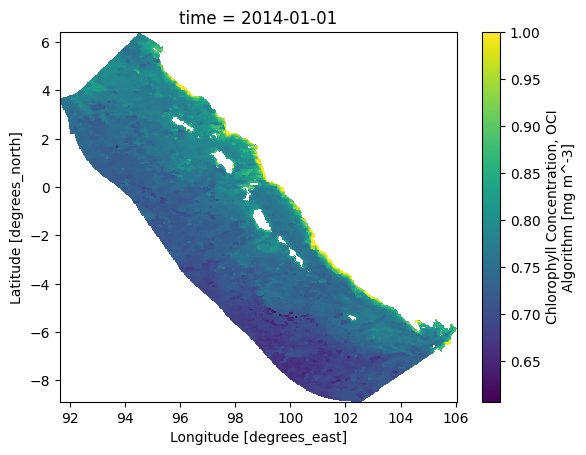

In [16]:
ds_train['chlor_a_3ddineof'].isel(time=0).plot()

# Prepare X, y Input

In [17]:
data_chl_raw = ds_train["chlor_a_3ddineof"].values.astype("float32")

# mask cropped sudah ada dari proses bounding box
mask_inside = mask_2d_cropped.astype("float32")

# broadcast mask ke seluruh waktu
mask_3d = np.broadcast_to(
    mask_inside,
    data_chl_raw.shape
).astype("float32")

# isi NaN luar WPP menjadi 0 untuk channel chlor_a
data_chl = np.nan_to_num(
    data_chl_raw,
    nan=0.0
).astype("float32")

# gabungkan menjadi 2 channel
# channel 0 = chlor_a
# channel 1 = mask WPP
data_input = np.stack(
    [data_chl, mask_3d],
    axis=-1
).astype("float32")

print("Shape data_chl   :", data_chl.shape)
print("Shape mask_3d    :", mask_3d.shape)
print("Shape data_input :", data_input.shape)

Shape data_chl   : (505, 367, 346)
Shape mask_3d    : (505, 367, 346)
Shape data_input : (505, 367, 346, 2)


In [18]:
var_name = "chlor_a_3ddineof"

print("Shape data_chl:", data_chl.shape)
print("Jumlah NaN setelah fill:", np.isnan(data_chl).sum())
print("Minimum:", np.nanmin(data_chl))
print("Maximum:", np.nanmax(data_chl))

Shape data_chl: (505, 367, 346)
Jumlah NaN setelah fill: 0
Minimum: 0.0
Maximum: 1.0


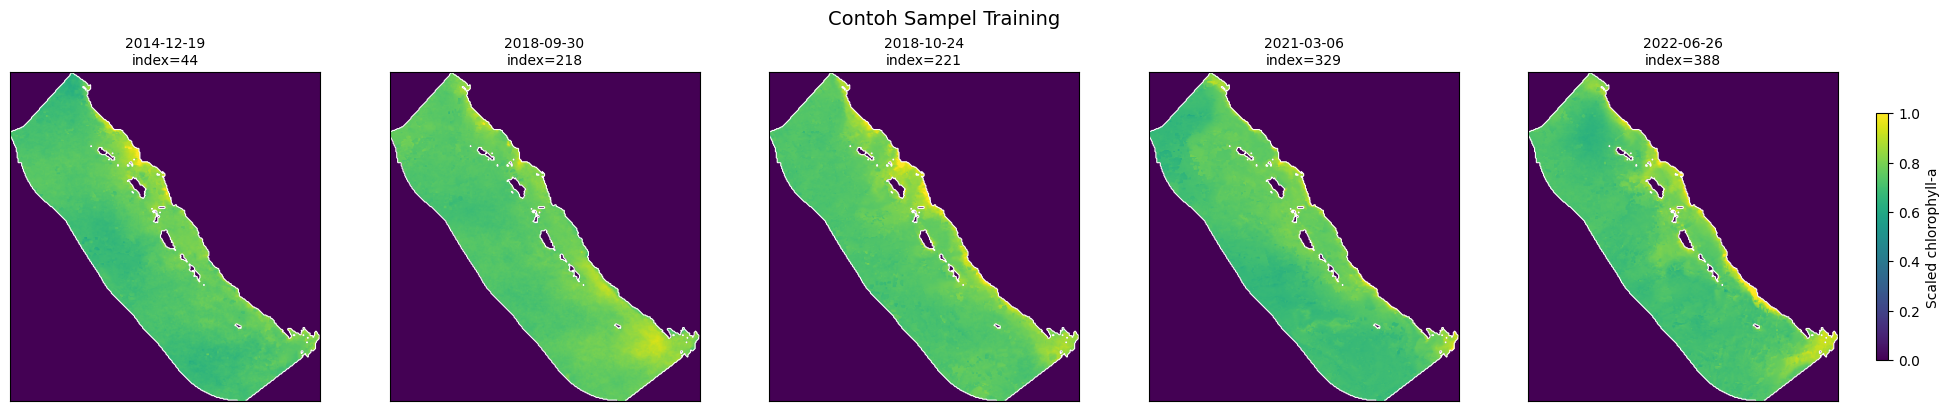

Random indices: [ 44 218 221 329 388]
Gambar tersimpan di: /kaggle/working/eda_5_random_chl_training_input.png


In [19]:
plot_random_training_frames(
    data_chl=data_chl,
    ds_train=ds_train,
    mask2d=mask_2d_cropped,
    n_random=5,
    random_seed=42,
    save_path="/kaggle/working/eda_5_random_chl_training_input.png",
    title="Contoh Sampel Training"
)

# Seq

In [20]:
def create_sequences_grid_masked(data_input, time_steps=3):
    """
    Membuat sequence ConvLSTM dari data 4D:
    time, lat, lon, channel

    channel 0 = chlor_a
    channel 1 = mask WPP

    X shape = sample, time_steps, lat, lon, channel
    y shape = sample, lat, lon, 1
    """

    X = []
    y = []

    n_time = data_input.shape[0]

    for i in range(n_time - time_steps):
        X.append(data_input[i:i + time_steps])

        # target hanya chlor_a, bukan mask
        y_target = data_input[i + time_steps, :, :, 0]
        y.append(y_target[..., np.newaxis])

    X = np.array(X, dtype="float32")
    y = np.array(y, dtype="float32")

    return X, y

In [21]:
time_steps = 3

X_seq, y_seq = create_sequences_grid_masked(
    data_input,
    time_steps=time_steps
)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (502, 3, 367, 346, 2)
y_seq shape: (502, 367, 346, 1)


# Splitting

In [22]:
time_index = ds_train.time.values
dates = pd.to_datetime(time_index[time_steps:])
dates

DatetimeIndex(['2014-01-25', '2014-02-02', '2014-02-10', '2014-02-18',
               '2014-02-26', '2014-03-06', '2014-03-14', '2014-03-22',
               '2014-03-30', '2014-04-07',
               ...
               '2024-10-23', '2024-10-31', '2024-11-08', '2024-11-16',
               '2024-11-24', '2024-12-02', '2024-12-10', '2024-12-18',
               '2024-12-26', '2025-01-01'],
              dtype='datetime64[ns]', length=502, freq=None)

In [23]:
train_idx = dates < "2024-01-01"
eval_idx = (dates >= "2024-01-01") & (dates <= "2024-06-30")
test_idx = (dates >= "2024-07-01") & (dates <= "2024-12-31")

X_train, y_train = X_seq[train_idx], y_seq[train_idx]
X_eval, y_eval = X_seq[eval_idx], y_seq[eval_idx]
X_test, y_test = X_seq[test_idx], y_seq[test_idx]

print("Jumlah total sequence:", len(X_seq))
print("Jumlah train sequence:", len(X_train))
print("Jumlah eval sequence:", len(X_eval))
print("Jumlah test sequence:", len(X_test))

print("Shape X_train:", X_train.shape)
print("Shape y_train:", y_train.shape)
print("Shape X_eval:", X_eval.shape)
print("Shape y_eval:", y_eval.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_test:", y_test.shape)

Jumlah total sequence: 502
Jumlah train sequence: 455
Jumlah eval sequence: 23
Jumlah test sequence: 23
Shape X_train: (455, 3, 367, 346, 2)
Shape y_train: (455, 367, 346, 1)
Shape X_eval: (23, 3, 367, 346, 2)
Shape y_eval: (23, 367, 346, 1)
Shape X_test: (23, 3, 367, 346, 2)
Shape y_test: (23, 367, 346, 1)


# Training

In [24]:
# Ambil input shape dari X_train

_, time_steps_model, n_lat, n_lon, n_channel = X_train.shape

print("Input shape:", (time_steps_model, n_lat, n_lon, n_channel))

Input shape: (3, 367, 346, 2)


In [25]:
# Model CONVLSTM
model = Sequential()

# ConvLSTM Layer 1
model.add(ConvLSTM2D(
    filters=64,
    kernel_size=(3,3),
    padding="same",
    activation="tanh",
    return_sequences=True,
    input_shape=(time_steps, n_lat, n_lon, 2)
))
model.add(BatchNormalization())

# ConvLSTM Layer 2
model.add(ConvLSTM2D(
    filters=32,
    kernel_size=(3,3),
    padding="same",
    activation="tanh",
    return_sequences=True
))
model.add(BatchNormalization())

# ConvLSTM Layer 3
model.add(ConvLSTM2D(
    filters=16,
    kernel_size=(3,3),
    padding="same",
    activation="tanh",
    return_sequences=False
))
model.add(BatchNormalization())

# Output layer
model.add(Conv2D(
    filters=1,
    kernel_size=(3,3),
    padding="same",
    activation="linear"
))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()


I0000 00:00:1781837973.214514      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 3, 367, 346,    │       152,320 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 367, 346,    │           256 │
│ (BatchNormalization)            │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 3, 367, 346,    │       110,720 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 367, 346,    │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 367, 346, 16)   │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 367, 346, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 367, 346, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,345 (1.11 MB)

 Trainable params: 291,121 (1.11 MB)

 Non-trainable params: 224 (896.00 B)

In [26]:
# callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True)
]

In [27]:
# train
history = model.fit(
    X_train, y_train,
    validation_data=(X_eval, y_eval),
    epochs=50,
    batch_size=2,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50


I0000 00:00:1781837983.606419      71 service.cc:152] XLA service 0x4632d400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781837983.606454      71 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781837984.711581      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781837991.822421      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - loss: 0.0862 - mae: 0.1485

228/228 ━━━━━━━━━━━━━━━━━━━━ 84s 312ms/step - loss: 0.0205 - mae: 0.0583 - val_loss: 0.0397 - val_mae: 0.1775 - learning_rate: 0.0010
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 8.7051e-04 - mae: 0.0161

228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 271ms/step - loss: 8.2222e-04 - mae: 0.0158 - val_loss: 0.0363 - val_mae: 0.1780 - learning_rate: 0.0010
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 8.2472e-04 - mae: 0.0170

...

228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 271ms/step - loss: 8.3163e-04 - mae: 0.0197 - val_loss: 5.6442e-04 - val_mae: 0.0206 - learning_rate: 0.0010
Epoch 13/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 7.6593e-04 - mae: 0.0191 - val_loss: 0.0015 - val_mae: 0.0359 - learning_rate: 0.0010
Epoch 14/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 7.7444e-04 - mae: 0.0196 - val_loss: 0.0019 - val_mae: 0.0350 - learning_rate: 0.0010
Epoch 15/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 7.4375e-04 - mae: 0.0179 - val_loss: 0.0018 - val_mae: 0.0398 - learning_rate: 0.0010
Epoch 16/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 7.9160e-04 - mae: 0.0189 - val_loss: 0.0011 - val_mae: 0.0290 - learning_rate: 0.0010
Epoch 17/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 7.3904e-04 - mae: 0.0185
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 7.0057e-04 - mae: 0.0180 - val_loss: 7.01

228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 5.0076e-04 - mae: 0.0137 - val_loss: 3.9920e-04 - val_mae: 0.0155 - learning_rate: 5.0000e-04
Epoch 19/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 5.1920e-04 - mae: 0.0134

228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 271ms/step - loss: 5.1392e-04 - mae: 0.0134 - val_loss: 3.5722e-04 - val_mae: 0.0114 - learning_rate: 5.0000e-04
Epoch 20/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 5.2160e-04 - mae: 0.0139 - val_loss: 3.7630e-04 - val_mae: 0.0115 - learning_rate: 5.0000e-04
Epoch 21/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 4.6689e-04 - mae: 0.0126

228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 5.0790e-04 - mae: 0.0138 - val_loss: 3.0455e-04 - val_mae: 0.0089 - learning_rate: 5.0000e-04
Epoch 22/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 5.1525e-04 - mae: 0.0141 - val_loss: 8.8881e-04 - val_mae: 0.0180 - learning_rate: 5.0000e-04
Epoch 23/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 4.7485e-04 - mae: 0.0135
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 5.3809e-04 - mae: 0.0152 - val_loss: 0.0013 - val_mae: 0.0335 - learning_rate: 5.0000e-04
Epoch 24/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 4.7314e-04 - mae: 0.0130 - val_loss: 9.9009e-04 - val_mae: 0.0216 - learning_rate: 2.5000e-04
Epoch 25/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 4.1851e-04 - mae: 0.0116 - val_loss: 3.3840e-04 - val_mae: 0.0129 - learning_rate: 2.5000e-04
Epoch 26/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 4.2169e-0

228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 3.9122e-04 - mae: 0.0114 - val_loss: 2.9805e-04 - val_mae: 0.0110 - learning_rate: 1.2500e-04
Epoch 32/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 4.1403e-04 - mae: 0.0119 - val_loss: 5.3024e-04 - val_mae: 0.0134 - learning_rate: 1.2500e-04
Epoch 33/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 3.7977e-04 - mae: 0.0114 - val_loss: 4.4570e-04 - val_mae: 0.0166 - learning_rate: 1.2500e-04
Epoch 34/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 3.9850e-04 - mae: 0.0118 - val_loss: 4.8362e-04 - val_mae: 0.0156 - learning_rate: 1.2500e-04
Epoch 35/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 3.8698e-04 - mae: 0.0115 - val_loss: 5.2079e-04 - val_mae: 0.0133 - learning_rate: 1.2500e-04
Epoch 36/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 4.2180e-04 - mae: 0.0119
Epoch 36: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
228/228 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - loss: 4.1034

In [28]:
# Prediksi data evaluation
y_pred_eval = model.predict(X_eval, batch_size=1)

y_eval_3d = y_eval[..., 0]
y_pred_eval_3d = y_pred_eval[..., 0]

# =====================================================
# 1. R2 SEMUA GRID
# =====================================================
r2_eval_all_grid = r2_score(
    y_eval_3d.reshape(-1),
    y_pred_eval_3d.reshape(-1)
)

# =====================================================
# 2. R2 HANYA AREA WPP
# =====================================================
mask_wpp = mask_2d_cropped.astype(bool)

# Broadcast mask 2D menjadi 3D mengikuti jumlah sample evaluation
mask_wpp_3d = np.broadcast_to(mask_wpp, y_eval_3d.shape)

# Ambil hanya nilai di dalam WPP
y_eval_wpp = y_eval_3d[mask_wpp_3d]
y_pred_eval_wpp = y_pred_eval_3d[mask_wpp_3d]

r2_eval_inside_wpp = r2_score(
    y_eval_wpp.reshape(-1),
    y_pred_eval_wpp.reshape(-1)
)

print(f"R2 Evaluation All Grid   : {r2_eval_all_grid:.4f}")
print(f"R2 Evaluation Inside WPP : {r2_eval_inside_wpp:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
R2 Evaluation All Grid   : 0.9976
R2 Evaluation Inside WPP : 0.7208


In [29]:
# data frame history
df_history = pd.DataFrame(history.history)
df_history["epoch"] = np.arange(1, len(df_history) + 1)
df_history.head()

,loss,mae,val_loss,val_mae,learning_rate,epoch
0,0.020476,0.058345,0.039719,0.177508,0.001,1
1,0.000822,0.015843,0.036343,0.178035,0.001,2
2,0.000745,0.016055,0.003722,0.057759,0.001,3
3,0.000830,0.018813,0.002620,0.040679,0.001,4
4,0.000739,0.017978,0.002005,0.041656,0.001,5


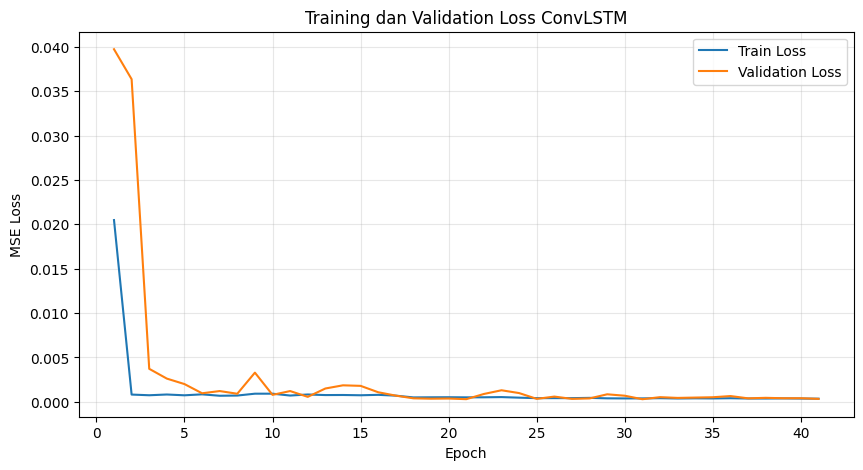

In [30]:
# =========================
# Plot training history: Loss
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df_history["epoch"], df_history["loss"], label="Train Loss")
plt.plot(df_history["epoch"], df_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training dan Validation Loss ConvLSTM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

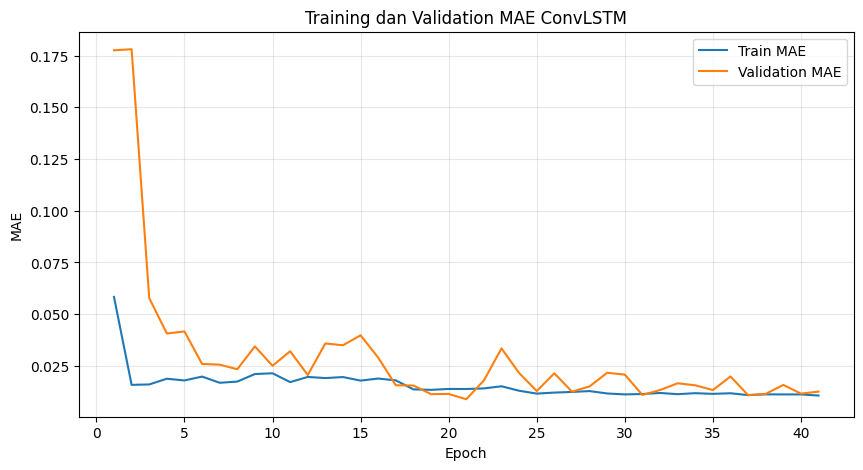

In [31]:
# =========================
# Plot training history: MAE
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df_history["epoch"], df_history["mae"], label="Train MAE")
plt.plot(df_history["epoch"], df_history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training dan Validation MAE ConvLSTM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Testing & Evaluasi

In [32]:
y_pred = model.predict(X_test)

# Flatten untuk evaluasi
y_test_flat = y_test.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

mae = mean_absolute_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))
r2 = r2_score(y_test_flat, y_pred_flat)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
MAE: 0.0115
RMSE: 0.0193
R^2: 0.9971


In [33]:
df_eval_area = evaluate_all_vs_inside_wpp(
    y_true=y_test,
    y_pred=y_pred,
    mask_2d_cropped=mask_2d_cropped
)

df_eval_area

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,area,n_data,MAE,RMSE,R2,Corr
0,All grid,2920586,0.011534,0.019273,0.997081,0.998610
1,Inside WPP,1013242,0.022973,0.031717,0.676935,0.824106
2,Outside WPP,1907344,0.005458,0.005865,0.000000,NaN


In [34]:
print("\n==================================================")
print("📦 MENYIMPAN SELURUH ARTIFAK KE KAGGLE OUTPUT...")
print("==================================================")

# ==========================================
# 1. SIMPAN DATASET XARRAY (ds_train)
# ==========================================
path_nc = '/kaggle/working/ds_train.nc'
ds_train.to_netcdf(path_nc)
print(f"✅ [1/4] Dataset Xarray tersimpan: {path_nc}")

# ==========================================
# 2. SIMPAN DATA SPLITTING + MASK + DATES (Format NPZ)
# ==========================================
path_npz = '/kaggle/working/data_splitting.npz'
np.savez_compressed(
    path_npz,
    X_train=X_train, y_train=y_train,
    X_eval=X_eval,   y_eval=y_eval,
    X_test=X_test,   y_test=y_test,
    mask_2d_cropped=mask_2d_cropped,
    dates_train=dates[train_idx],
    dates_eval=dates[eval_idx],
    dates_test=dates[test_idx]
)
print(f"✅ [2/4] Data Splitting & Variabel Ekstra tersimpan: {path_npz}")

# ==========================================
# 3. SIMPAN RIWAYAT TRAINING (df_history)
# ==========================================
path_history = '/kaggle/working/df_history.csv'
# Jika df_history belum didefinisikan dari model.fit, aktifkan baris di bawah ini:
# df_history = pd.DataFrame(history.history)
df_history.to_csv(path_history, index=False)
print(f"✅ [3/4] Riwayat Training tersimpan: {path_history}")

# ==========================================
# 4. SIMPAN MODEL TERAKHIR
# ==========================================
# Backup untuk menyimpan model kondisi epoch paling terakhir
path_model_terakhir = '/kaggle/working/model_terakhir.h5'
model.save(path_model_terakhir)
print(f"✅ [4/4] Model Kondisi Terakhir tersimpan: {path_model_terakhir}")

print("\n🎉 SEMUA PROSES PENYIMPANAN SELESAI!")
print("Silakan cek panel 'Output' di sebelah kanan Kaggle Anda untuk mengunduh:")
print("- ds_train.nc")
print("- data_splitting.npz")
print("- df_history.csv")
print("- best_model.h5 (Pastikan ModelCheckpoint Anda juga di-set ke /kaggle/working/best_model.h5)")
print("- model_terakhir.h5")
print("- scaler_klorofil.pkl (Yang sudah Anda simpan di awal)")


📦 MENYIMPAN SELURUH ARTIFAK KE KAGGLE OUTPUT...
✅ [1/4] Dataset Xarray tersimpan: /kaggle/working/ds_train.nc


✅ [2/4] Data Splitting & Variabel Ekstra tersimpan: /kaggle/working/data_splitting.npz
✅ [3/4] Riwayat Training tersimpan: /kaggle/working/df_history.csv
✅ [4/4] Model Kondisi Terakhir tersimpan: /kaggle/working/model_terakhir.h5

🎉 SEMUA PROSES PENYIMPANAN SELESAI!
Silakan cek panel 'Output' di sebelah kanan Kaggle Anda untuk mengunduh:
- ds_train.nc
- data_splitting.npz
- df_history.csv
- best_model.h5 (Pastikan ModelCheckpoint Anda juga di-set ke /kaggle/working/best_model.h5)
- model_terakhir.h5
- scaler_klorofil.pkl (Yang sudah Anda simpan di awal)


In [35]:
import os
import tensorflow as tf

# Path model H5 yang sudah ada
path_best_h5 = "/kaggle/working/best_model.h5"
path_last_h5 = "/kaggle/working/model_terakhir.h5"

# Path output Keras
path_best_keras = "/kaggle/working/best_model.keras"
path_last_keras = "/kaggle/working/model_terakhir.keras"

# Load model H5
best_model = tf.keras.models.load_model(path_best_h5, compile=False)
last_model = tf.keras.models.load_model(path_last_h5, compile=False)

# Save ulang ke format .keras
best_model.save(path_best_keras)
last_model.save(path_last_keras)

print("✅ Best model H5 tersimpan     :", path_best_h5)
print("✅ Best model Keras tersimpan  :", path_best_keras)
print("✅ Last model H5 tersimpan     :", path_last_h5)
print("✅ Last model Keras tersimpan  :", path_last_keras)

print("\nCek file:")
print("best_model.keras ada      :", os.path.exists(path_best_keras))
print("model_terakhir.keras ada  :", os.path.exists(path_last_keras))

✅ Best model H5 tersimpan     : /kaggle/working/best_model.h5
✅ Best model Keras tersimpan  : /kaggle/working/best_model.keras
✅ Last model H5 tersimpan     : /kaggle/working/model_terakhir.h5
✅ Last model Keras tersimpan  : /kaggle/working/model_terakhir.keras

Cek file:
best_model.keras ada      : True
model_terakhir.keras ada  : True
